Data Loading and Feature Engineering
Let’s use pandas to load a copy of the titanic dataset. The following shows how to apply separate preprocessing on numerical and categorical features.

We further include two random variables that are not correlated in any way with the target variable (`survived`):

*   `random_num` is a high cardinality numerical variable (as many unique values as records).
*   `random_cat` is a low cardinality categorical variable (3 possible values).

In [2]:
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)
rng = np.random.RandomState(seed=42)
X["random_cat"] = rng.randint(3, size=X.shape[0])
X["random_num"] = rng.randn(X.shape[0])

categorical_columns = ["pclass", "sex", "embarked", "random_cat"]
numerical_columns = ["age", "sibsp", "parch", "fare", "random_num"]

X = X[categorical_columns + numerical_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

We define a predictive model based on a random forest. Therefore, we will make the following preprocessing steps:

* use `OrdinalEncoder` to encode the categorical features;

* use `SimpleImputer` to fill missing values for numerical features using a mean strategy.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1
)
numerical_pipe = SimpleImputer(strategy="mean")

preprocessing = ColumnTransformer(
    [
        ("cat", categorical_encoder, categorical_columns),
        ("num", numerical_pipe, numerical_columns),
    ],
    verbose_feature_names_out=False,
)

rf = Pipeline(
    [
        ("preprocess", preprocessing),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)
rf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OrdinalEncoder(encoded_missing_value=-1,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['pclass', 'sex', 'embarked',
                                                   'random_cat']),
                                                 ('num', SimpleImputer(),
                                                  ['age', 'sibsp', 'parch',
                                                   'fare', 'random_num'])],
                                   verbose_feature_names_out=False)),
                ('classifier', RandomForestClassifier(random_state=42))])

# Accuracy of the Model
Before inspecting the feature importances, it is important to check that the model predictive performance is high enough. Indeed, there would be little interest in inspecting the important features of a non-predictive model.

In [4]:
print(f"RF train accuracy: {rf.score(X_train, y_train):.3f}")
print(f"RF test accuracy: {rf.score(X_test, y_test):.3f}")

RF train accuracy: 1.000
RF test accuracy: 0.814


Here, one can observe that the train accuracy is very high (the forest model has enough capacity to completely memorize the training set) but it can still generalize well enough to the test set thanks to the built-in bagging of random forests.

It might be possible to trade some accuracy on the training set for a slightly better accuracy on the test set by limiting the capacity of the trees (for instance by setting `min_samples_leaf=5` or `min_samples_leaf=10`) so as to limit overfitting while not introducing too much underfitting.

However, let us keep our high capacity random forest model for now so that we can illustrate some pitfalls about feature importance on variables with many unique values.

# Tree’s Feature Importance from Mean Decrease in Impurity (MDI)

The impurity-based feature importance ranks the numerical features to be the most important features. As a result, the non-predictive `random_num` variable is ranked as one of the most important features!

This problem stems from two limitations of impurity-based feature importances:

* impurity-based importances are biased towards high cardinality features;

* impurity-based importances are computed on training set statistics and therefore do not reflect the ability of feature to be useful to make predictions that generalize to the test set (when the model has enough capacity).

The bias towards high cardinality features explains why the `random_num` has a really large importance in comparison with `random_cat` while we would expect that both random features have a null importance.

The fact that we use training set statistics explains why both the `random_num` and `random_cat` features have a non-null importance.

In [5]:
import pandas as pd

feature_names = rf[:-1].get_feature_names_out()

mdi_importances = pd.Series(
    rf[-1].feature_importances_, index=feature_names
).sort_values(ascending=True)

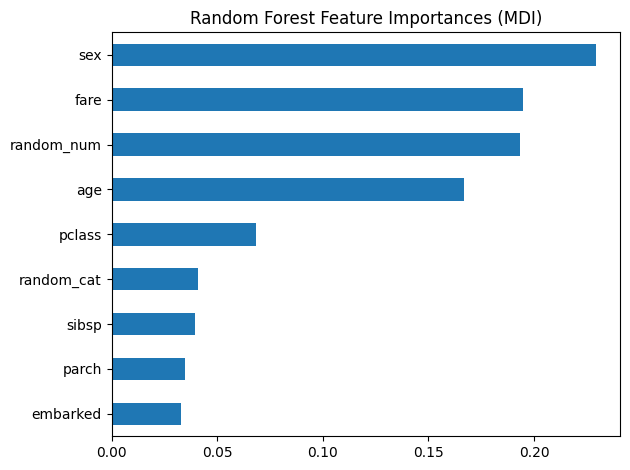

In [6]:
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

As an alternative, the permutation importances of rf are computed on a held out test set. This shows that the low cardinality categorical feature, sex and pclass are the most important features. Indeed, permuting the values of these features will lead to the most decrease in accuracy score of the model on the test set.

Also, note that both random features have very low importances (close to 0) as expected.

<Axes: title={'center': 'Permutation Importances (test set)'}, xlabel='Decrease in accuracy score'>

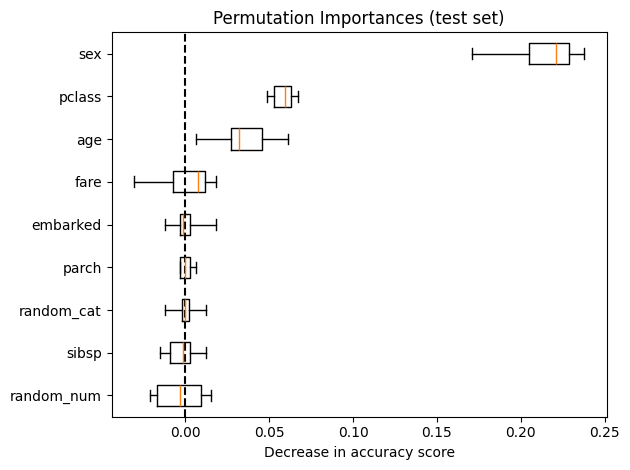

In [7]:
import matplotlib
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.utils.fixes import parse_version

# `pandas.DataFrame.plot.box` forwards its `vert` and `labels` arguments to matplotlib.
# These arguments are deprecated and removed in version 3.11 and 3.9, respectively. We
# therefore draw the horizontal boxplots directly with matplotlib in a way that is
# compatible with the matplotlib versions we support. As a user you probably can write
# simpler code by using `pandas.DataFrame.plot.box` directly with the appropriate
# arguments.
tick_labels_parameter_name = (
    "tick_labels"
    if parse_version(matplotlib.__version__) >= parse_version("3.9")
    else "labels"
)
orientation_dict = (
    {"orientation": "horizontal"}
    if parse_version(matplotlib.__version__) >= parse_version("3.10")
    else {"vert": False}
)


def plot_importances_box(importances, title):
    fig, ax = plt.subplots()
    ax.boxplot(
        importances.values,
        whis=10,
        **orientation_dict,
        **{tick_labels_parameter_name: importances.columns},
    )
    ax.set_title(title)
    ax.axvline(x=0, color="k", linestyle="--")
    ax.set_xlabel("Decrease in accuracy score")
    fig.tight_layout()
    return ax


result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
plot_importances_box(importances, "Permutation Importances (test set)")

It is also possible to compute the permutation importances on the training set. This reveals that `random_num` and `random_cat` get a significantly higher importance ranking than when computed on the test set. The difference between those two plots is a confirmation that the RF model has enough capacity to use that random numerical and categorical features to overfit.

<Axes: title={'center': 'Permutation Importances (train set)'}, xlabel='Decrease in accuracy score'>

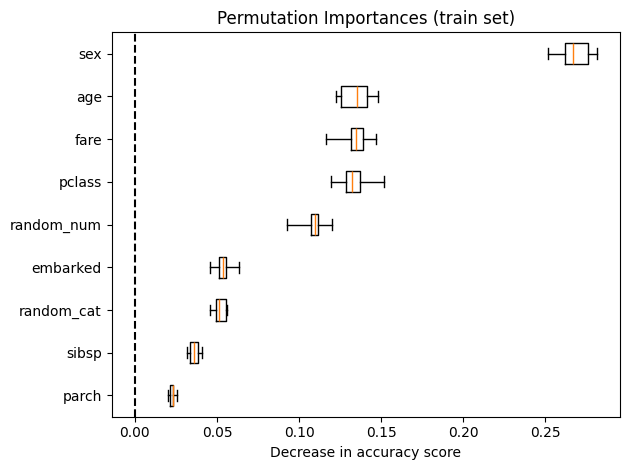

In [8]:
result = permutation_importance(
    rf, X_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
plot_importances_box(importances, "Permutation Importances (train set)")

We can further retry the experiment by limiting the capacity of the trees to overfit by setting `min_samples_leaf` at 20 data points.

In [9]:
rf.set_params(classifier__min_samples_leaf=20).fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OrdinalEncoder(encoded_missing_value=-1,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['pclass', 'sex', 'embarked',
                                                   'random_cat']),
                                                 ('num', SimpleImputer(),
                                                  ['age', 'sibsp', 'parch',
                                                   'fare', 'random_num'])],
                                   verbose_feature_names_out=False)),
                ('classifier',
                 RandomForestClassifier(min_samples_leaf=20, random_state=42))])

Observing the accuracy score on the training and testing set, we observe that the two metrics are very similar now. Therefore, our model is not overfitting anymore. We can then check the permutation importances with this new model.

In [10]:
print(f"RF train accuracy: {rf.score(X_train, y_train):.3f}")
print(f"RF test accuracy: {rf.score(X_test, y_test):.3f}")

RF train accuracy: 0.810
RF test accuracy: 0.832


In [11]:
train_result = permutation_importance(
    rf, X_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)
test_results = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_importances_idx = train_result.importances_mean.argsort()

In [12]:
train_importances = pd.DataFrame(
    train_result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
test_importances = pd.DataFrame(
    test_results.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)

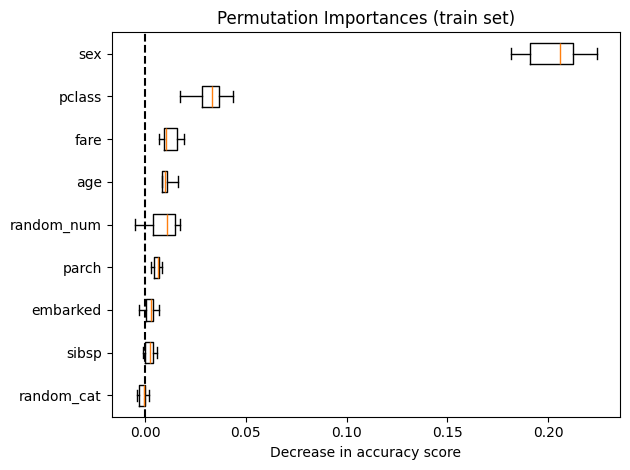

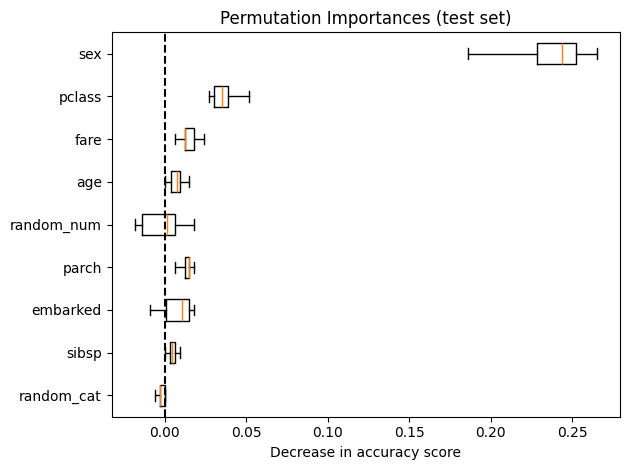

In [13]:
for name, importances in zip(["train", "test"], [train_importances, test_importances]):
    plot_importances_box(importances, f"Permutation Importances ({name} set)")

Now, we can observe that on both sets, the random_num and random_cat features have a lower importance compared to the overfitting random forest. However, the conclusions regarding the importance of the other features are still valid.